In [1]:
import pickle
import numpy as np
from pathlib import Path
from scipy.signal import butter, sosfiltfilt, find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

SUBJECTS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 
            'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

DATA_DIR = Path('model/wesad')
WINDOW_SIZE_SEC = 45
FS = 700

EMOTION_NAMES_4CLASS = {0: 'Baseline', 1: 'Stress', 2: 'Amusement', 3: 'Meditation'}
EMOTION_NAMES_BINARY = {0: 'Non-Stress', 1: 'Stress'}
EMOTION_NAMES = {1: 'Baseline', 2: 'Stress', 3: 'Amusement', 4: 'Meditation'}

SIMPLE_FEATURE_NAMES = ['mean_hr', 'sdnn', 'rmssd', 'pnn50']
SIMPLE_FEATURE_INDICES = [7, 1, 2, 4]

def extract_extended_hrv_features(ecg_segment, fs=700):
    if len(ecg_segment) < int(fs * 10):
        return None
    
    sos = butter(2, [5, 15], btype='band', fs=fs, output='sos')
    ecg_band = sosfiltfilt(sos, ecg_segment)
    ecg_squared = ecg_band ** 2
    window_size = int(0.15 * fs)
    ecg_integrated = np.convolve(ecg_squared, np.ones(window_size)/window_size, mode='same')
    
    threshold = np.mean(ecg_integrated) + 0.5 * np.std(ecg_integrated)
    r_peaks, _ = find_peaks(ecg_integrated, height=threshold, distance=int(0.4 * fs))
    
    if len(r_peaks) < 10:
        return None
    
    rr_samples = np.diff(r_peaks)
    rr_ms = (rr_samples / fs) * 1000
    
    rr_ms = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]
    if len(rr_ms) < 8:
        return None
    
    nn_diffs = np.diff(rr_ms)
    
    mean_rr = np.mean(rr_ms)
    sdnn = np.std(rr_ms, ddof=1)
    rmssd = np.sqrt(np.mean(nn_diffs ** 2))
    nn50 = np.sum(np.abs(nn_diffs) > 50)
    pnn50 = (nn50 / len(nn_diffs)) * 100 if len(nn_diffs) > 0 else 0
    mean_hr = 60000 / mean_rr
    
    features = [mean_rr, sdnn, rmssd, nn50, pnn50, 0, 0, mean_hr, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    
    return features

def load_subject_extended(subject_id='S2', window_size_sec=WINDOW_SIZE_SEC, fs=FS):
    data_path = DATA_DIR / subject_id / f'{subject_id}.pkl'
    
    if not data_path.exists():
        print(f"File not found: {data_path}")
        return None, None
    
    with open(data_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    
    ecg_raw = data['signal']['chest']['ECG'].flatten()
    labels = data['label'].flatten()
    
    sos = butter(4, [0.5, 100], btype='band', fs=fs, output='sos')
    ecg_filtered = sosfiltfilt(sos, ecg_raw)
    
    window_samples = fs * window_size_sec
    step_samples = window_samples // 3
    
    X = []
    y = []
    
    for i in range(0, len(ecg_filtered) - window_samples, step_samples):
        ecg_window = ecg_filtered[i:i+window_samples]
        label_window = labels[i:i+window_samples]
        
        unique, counts = np.unique(label_window.astype(int), return_counts=True)
        main_label = unique[np.argmax(counts)]
        label_purity = counts.max() / counts.sum()
        
        if main_label == 0 or label_purity < 0.95:
            continue
        
        hrv_features = extract_extended_hrv_features(ecg_window, fs)
        
        if hrv_features is None:
            continue
        
        X.append(hrv_features)
        y.append(main_label)
    
    X = np.array(X) if X else None
    y = np.array(y) if y else None
    
    return X, y

print("=" * 80)
print("LOADING DATA FOR SIMPLE 4-FEATURE MODEL")
print("=" * 80 + "\n")

all_X = []
all_y = []
subject_ids = []

for subject in SUBJECTS:
    X, y = load_subject_extended(subject)
    
    if X is not None and len(X) > 0:
        all_X.append(X)
        all_y.append(y)
        subject_ids.extend([subject] * len(X))
        print(f"{subject}: {len(X)} windows")

X_all = np.vstack(all_X)
y_all = np.hstack(all_y)
subject_ids = np.array(subject_ids)

print("\n" + "=" * 80)
print("EXTRACTING 4 FEATURES: mean_hr, sdnn, rmssd, pnn50")
print("=" * 80)

X_simple = X_all[:, SIMPLE_FEATURE_INDICES]

print(f"Total windows: {len(X_simple)}")
print(f"X_simple.shape: {X_simple.shape} (4 features: {SIMPLE_FEATURE_NAMES})")

print(f"\nClass distribution:")
for emotion_id in [1, 2, 3, 4]:
    count = np.sum(y_all == emotion_id)
    pct = 100 * count / len(y_all)
    print(f"{EMOTION_NAMES[emotion_id]:15s} {count:3d} ({pct:5.1f}%)")

LOADING DATA FOR SIMPLE 4-FEATURE MODEL

S2: 180 windows
S3: 188 windows
S4: 186 windows
S5: 190 windows
S6: 189 windows
S7: 185 windows
S8: 189 windows
S9: 191 windows
S10: 194 windows
S11: 189 windows
S13: 189 windows
S14: 192 windows
S15: 188 windows
S16: 190 windows
S17: 194 windows

EXTRACTING 4 FEATURES: mean_hr, sdnn, rmssd, pnn50
Total windows: 2834
X_simple.shape: (2834, 4) (4 features: ['mean_hr', 'sdnn', 'rmssd', 'pnn50'])

Class distribution:
Baseline        1133 ( 40.0%)
Stress          624 ( 22.0%)
Amusement       330 ( 11.6%)
Meditation      703 ( 24.8%)


In [2]:
X_simple = np.nan_to_num(X_simple, nan=0, posinf=0, neginf=0)

scaler_simple = StandardScaler()
X_scaled = scaler_simple.fit_transform(X_simple)

print("=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

print(f"\nFeatures normalized: {X_scaled.shape[1]} features")
print(f"Samples: {X_scaled.shape[0]}")

print(f"\nFeature statistics:")
for i, fname in enumerate(SIMPLE_FEATURE_NAMES):
    print(f"  {fname:12s} Mean: {X_simple[:, i].mean():8.2f}, Std: {X_simple[:, i].std():8.2f}")

valid_mask = np.isin(y_all, [1, 2, 3, 4])
X_filtered = X_scaled[valid_mask]
y_filtered = y_all[valid_mask]

print(f"\nTotal data after filtering: {len(X_filtered)} windows (classes 1-4)")

DATA PREPROCESSING

Features normalized: 4 features
Samples: 2834

Feature statistics:
  mean_hr      Mean:    77.02, Std:    16.64
  sdnn         Mean:    75.08, Std:    36.47
  rmssd        Mean:    57.86, Std:    39.73
  pnn50        Mean:    25.58, Std:    19.66

Total data after filtering: 2790 windows (classes 1-4)


In [3]:
print("=" * 80)
print("TRAINING BINARY MODELS (Stress vs Non-Stress)")
print("=" * 80)

y_binary = (y_filtered == 2).astype(int)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_filtered, y_binary, test_size=0.15, random_state=42, stratify=y_binary
)

sample_weights_b = compute_sample_weight('balanced', y_train_b)

print(f"Train: {len(X_train_b)}, Test: {len(X_test_b)}")
print(f"Class distribution: Non-Stress={np.sum(y_binary==0)}, Stress={np.sum(y_binary==1)}")

models_binary = {}
results_binary = {}

xgb_binary = XGBClassifier(
    n_estimators=1500, max_depth=10, learning_rate=0.02,
    min_child_weight=1, subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.01, reg_lambda=0.5, gamma=0.05,
    scale_pos_weight=np.sum(y_binary==0)/np.sum(y_binary==1),
    random_state=42, n_jobs=1, verbosity=0
)
xgb_binary.fit(X_train_b, y_train_b, sample_weight=sample_weights_b)
y_pred_xgb = xgb_binary.predict(X_test_b)
models_binary['XGBoost'] = xgb_binary
results_binary['XGBoost'] = {
    'f1_macro': f1_score(y_test_b, y_pred_xgb, average='macro'),
    'f1_weighted': f1_score(y_test_b, y_pred_xgb, average='weighted'),
    'accuracy': accuracy_score(y_test_b, y_pred_xgb),
    'precision': precision_score(y_test_b, y_pred_xgb, average='weighted'),
    'recall': recall_score(y_test_b, y_pred_xgb, average='weighted'),
    'y_pred': y_pred_xgb,
    'y_test': y_test_b
}

cat_binary = CatBoostClassifier(
    iterations=1500, depth=10, learning_rate=0.02,
    random_state=42, verbose=False, class_weights=[1, np.sum(y_binary==0)/np.sum(y_binary==1)]
)
cat_binary.fit(X_train_b, y_train_b, sample_weight=sample_weights_b)
y_pred_cat = cat_binary.predict(X_test_b)
models_binary['CatBoost'] = cat_binary
results_binary['CatBoost'] = {
    'f1_macro': f1_score(y_test_b, y_pred_cat, average='macro'),
    'f1_weighted': f1_score(y_test_b, y_pred_cat, average='weighted'),
    'accuracy': accuracy_score(y_test_b, y_pred_cat),
    'precision': precision_score(y_test_b, y_pred_cat, average='weighted'),
    'recall': recall_score(y_test_b, y_pred_cat, average='weighted'),
    'y_pred': y_pred_cat,
    'y_test': y_test_b
}

lgb_binary = LGBMClassifier(
    n_estimators=1500, max_depth=10, learning_rate=0.02,
    subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.01, reg_lambda=0.5,
    class_weight='balanced',
    random_state=42, n_jobs=1, verbosity=-1
)
lgb_binary.fit(X_train_b, y_train_b, sample_weight=sample_weights_b)
y_pred_lgb = lgb_binary.predict(X_test_b)
models_binary['LightGBM'] = lgb_binary
results_binary['LightGBM'] = {
    'f1_macro': f1_score(y_test_b, y_pred_lgb, average='macro'),
    'f1_weighted': f1_score(y_test_b, y_pred_lgb, average='weighted'),
    'accuracy': accuracy_score(y_test_b, y_pred_lgb),
    'precision': precision_score(y_test_b, y_pred_lgb, average='weighted'),
    'recall': recall_score(y_test_b, y_pred_lgb, average='weighted'),
    'y_pred': y_pred_lgb,
    'y_test': y_test_b
}

rf_binary = RandomForestClassifier(
    n_estimators=500, max_depth=20, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=1
)
rf_binary.fit(X_train_b, y_train_b, sample_weight=sample_weights_b)
y_pred_rf = rf_binary.predict(X_test_b)
models_binary['RandomForest'] = rf_binary
results_binary['RandomForest'] = {
    'f1_macro': f1_score(y_test_b, y_pred_rf, average='macro'),
    'f1_weighted': f1_score(y_test_b, y_pred_rf, average='weighted'),
    'accuracy': accuracy_score(y_test_b, y_pred_rf),
    'precision': precision_score(y_test_b, y_pred_rf, average='weighted'),
    'recall': recall_score(y_test_b, y_pred_rf, average='weighted'),
    'y_pred': y_pred_rf,
    'y_test': y_test_b
}

print("\nBinary Model Results:")
print("-" * 80)
for model_name, res in results_binary.items():
    print(f"{model_name:15s} F1-macro: {res['f1_macro']:.4f}, F1-weighted: {res['f1_weighted']:.4f}, "
          f"Acc: {res['accuracy']:.4f}, Prec: {res['precision']:.4f}, Rec: {res['recall']:.4f}")

best_binary_name = max(results_binary.keys(), key=lambda k: results_binary[k]['f1_weighted'])
best_binary_model = models_binary[best_binary_name]
print(f"\nBest Binary Model: {best_binary_name} (F1-weighted: {results_binary[best_binary_name]['f1_weighted']:.4f})")

TRAINING BINARY MODELS (Stress vs Non-Stress)
Train: 2371, Test: 419
Class distribution: Non-Stress=2166, Stress=624

Binary Model Results:
--------------------------------------------------------------------------------
XGBoost         F1-macro: 0.8445, F1-weighted: 0.8885, Acc: 0.8854, Prec: 0.8946, Rec: 0.8854
CatBoost        F1-macro: 0.8467, F1-weighted: 0.8879, Acc: 0.8831, Prec: 0.9009, Rec: 0.8831
LightGBM        F1-macro: 0.8380, F1-weighted: 0.8838, Acc: 0.8807, Prec: 0.8900, Rec: 0.8807
RandomForest    F1-macro: 0.8535, F1-weighted: 0.8965, Acc: 0.8950, Prec: 0.8988, Rec: 0.8950

Best Binary Model: RandomForest (F1-weighted: 0.8965)


In [4]:
print("=" * 80)
print("TRAINING 4-CLASS MODELS (Baseline, Stress, Amusement, Meditation)")
print("=" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.15, random_state=42, stratify=y_filtered
)

y_train_enc = y_train.astype(int) - 1
y_test_enc = y_test.astype(int) - 1

sample_weights = compute_sample_weight('balanced', y_train_enc)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

models_4class = {}
results_4class = {}

xgb_4class = XGBClassifier(
    n_estimators=1500, max_depth=12, learning_rate=0.02,
    min_child_weight=1, subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.01, reg_lambda=0.5, gamma=0.05,
    random_state=42, n_jobs=1, verbosity=0
)
xgb_4class.fit(X_train, y_train_enc, sample_weight=sample_weights)
y_pred_xgb = xgb_4class.predict(X_test)
models_4class['XGBoost'] = xgb_4class
results_4class['XGBoost'] = {
    'f1_macro': f1_score(y_test_enc, y_pred_xgb, average='macro'),
    'f1_weighted': f1_score(y_test_enc, y_pred_xgb, average='weighted'),
    'accuracy': accuracy_score(y_test_enc, y_pred_xgb),
    'precision': precision_score(y_test_enc, y_pred_xgb, average='weighted'),
    'recall': recall_score(y_test_enc, y_pred_xgb, average='weighted'),
    'y_pred': y_pred_xgb,
    'y_test': y_test_enc
}

cat_4class = CatBoostClassifier(
    iterations=1500, depth=12, learning_rate=0.02,
    random_state=42, verbose=False
)
cat_4class.fit(X_train, y_train_enc, sample_weight=sample_weights)
y_pred_cat = cat_4class.predict(X_test)
models_4class['CatBoost'] = cat_4class
results_4class['CatBoost'] = {
    'f1_macro': f1_score(y_test_enc, y_pred_cat, average='macro'),
    'f1_weighted': f1_score(y_test_enc, y_pred_cat, average='weighted'),
    'accuracy': accuracy_score(y_test_enc, y_pred_cat),
    'precision': precision_score(y_test_enc, y_pred_cat, average='weighted'),
    'recall': recall_score(y_test_enc, y_pred_cat, average='weighted'),
    'y_pred': y_pred_cat,
    'y_test': y_test_enc
}

lgb_4class = LGBMClassifier(
    n_estimators=1500, max_depth=12, learning_rate=0.02,
    subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.01, reg_lambda=0.5,
    class_weight='balanced',
    random_state=42, n_jobs=1, verbosity=-1
)
lgb_4class.fit(X_train, y_train_enc, sample_weight=sample_weights)
y_pred_lgb = lgb_4class.predict(X_test)
models_4class['LightGBM'] = lgb_4class
results_4class['LightGBM'] = {
    'f1_macro': f1_score(y_test_enc, y_pred_lgb, average='macro'),
    'f1_weighted': f1_score(y_test_enc, y_pred_lgb, average='weighted'),
    'accuracy': accuracy_score(y_test_enc, y_pred_lgb),
    'precision': precision_score(y_test_enc, y_pred_lgb, average='weighted'),
    'recall': recall_score(y_test_enc, y_pred_lgb, average='weighted'),
    'y_pred': y_pred_lgb,
    'y_test': y_test_enc
}

rf_4class = RandomForestClassifier(
    n_estimators=500, max_depth=20, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=1
)
rf_4class.fit(X_train, y_train_enc, sample_weight=sample_weights)
y_pred_rf = rf_4class.predict(X_test)
models_4class['RandomForest'] = rf_4class
results_4class['RandomForest'] = {
    'f1_macro': f1_score(y_test_enc, y_pred_rf, average='macro'),
    'f1_weighted': f1_score(y_test_enc, y_pred_rf, average='weighted'),
    'accuracy': accuracy_score(y_test_enc, y_pred_rf),
    'precision': precision_score(y_test_enc, y_pred_rf, average='weighted'),
    'recall': recall_score(y_test_enc, y_pred_rf, average='weighted'),
    'y_pred': y_pred_rf,
    'y_test': y_test_enc
}

print("\n4-Class Model Results:")
print("-" * 80)
for model_name, res in results_4class.items():
    print(f"{model_name:15s} F1-macro: {res['f1_macro']:.4f}, F1-weighted: {res['f1_weighted']:.4f}, "
          f"Acc: {res['accuracy']:.4f}, Prec: {res['precision']:.4f}, Rec: {res['recall']:.4f}")

best_4class_name = max(results_4class.keys(), key=lambda k: results_4class[k]['f1_weighted'])
best_4class_model = models_4class[best_4class_name]
print(f"\nBest 4-Class Model: {best_4class_name} (F1-weighted: {results_4class[best_4class_name]['f1_weighted']:.4f})")

TRAINING 4-CLASS MODELS (Baseline, Stress, Amusement, Meditation)
Train: 2371, Test: 419

4-Class Model Results:
--------------------------------------------------------------------------------
XGBoost         F1-macro: 0.6178, F1-weighted: 0.6535, Acc: 0.6563, Prec: 0.6527, Rec: 0.6563
CatBoost        F1-macro: 0.6201, F1-weighted: 0.6537, Acc: 0.6516, Prec: 0.6603, Rec: 0.6516
LightGBM        F1-macro: 0.5989, F1-weighted: 0.6305, Acc: 0.6277, Prec: 0.6374, Rec: 0.6277
RandomForest    F1-macro: 0.6232, F1-weighted: 0.6557, Acc: 0.6563, Prec: 0.6578, Rec: 0.6563

Best 4-Class Model: RandomForest (F1-weighted: 0.6557)


VISUALIZATION: F1-SCORE COMPARISON


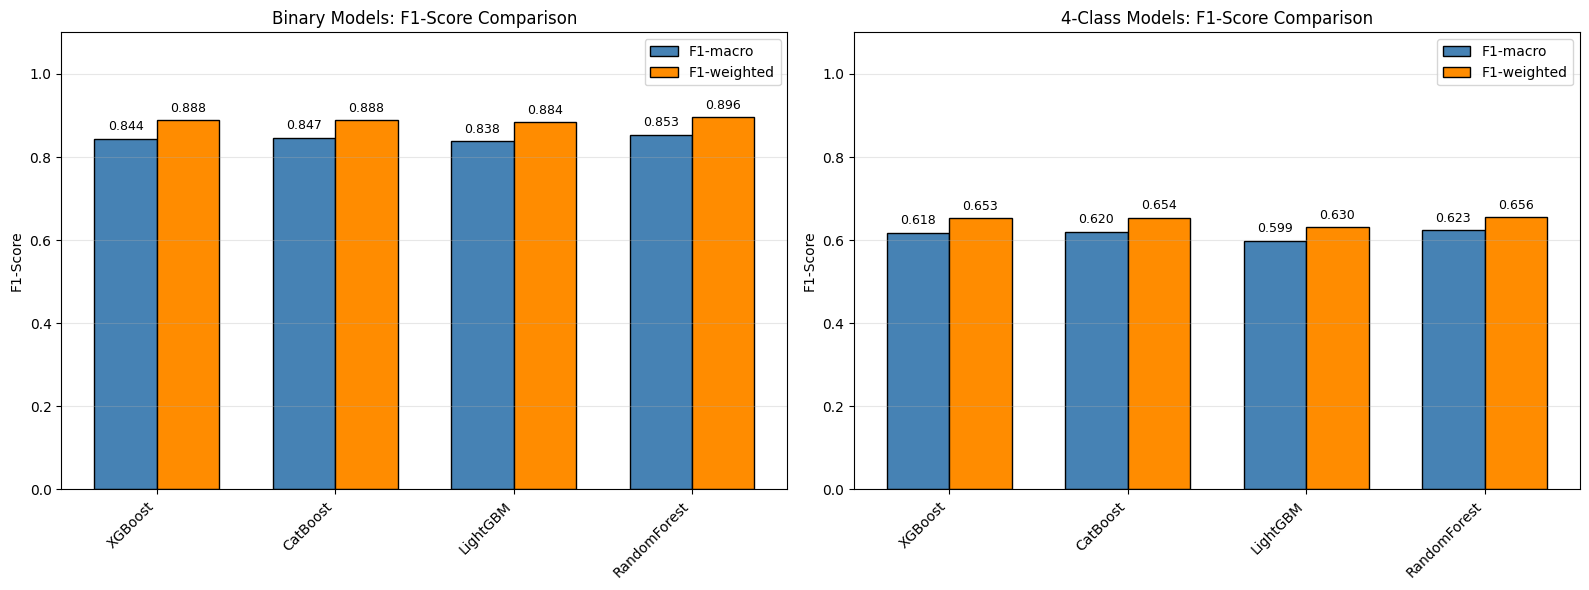

In [5]:
print("=" * 80)
print("VISUALIZATION: F1-SCORE COMPARISON")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = list(results_binary.keys())
f1_macro_binary = [results_binary[m]['f1_macro'] for m in model_names]
f1_weighted_binary = [results_binary[m]['f1_weighted'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

axes[0].bar(x - width/2, f1_macro_binary, width, label='F1-macro', color='steelblue', edgecolor='black')
axes[0].bar(x + width/2, f1_weighted_binary, width, label='F1-weighted', color='darkorange', edgecolor='black')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Binary Models: F1-Score Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].set_ylim([0, 1.1])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

for i, (macro, weighted) in enumerate(zip(f1_macro_binary, f1_weighted_binary)):
    axes[0].text(i - width/2, macro + 0.02, f'{macro:.3f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, weighted + 0.02, f'{weighted:.3f}', ha='center', fontsize=9)

model_names_4 = list(results_4class.keys())
f1_macro_4 = [results_4class[m]['f1_macro'] for m in model_names_4]
f1_weighted_4 = [results_4class[m]['f1_weighted'] for m in model_names_4]

x = np.arange(len(model_names_4))
axes[1].bar(x - width/2, f1_macro_4, width, label='F1-macro', color='steelblue', edgecolor='black')
axes[1].bar(x + width/2, f1_weighted_4, width, label='F1-weighted', color='darkorange', edgecolor='black')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('4-Class Models: F1-Score Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names_4, rotation=45, ha='right')
axes[1].set_ylim([0, 1.1])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

for i, (macro, weighted) in enumerate(zip(f1_macro_4, f1_weighted_4)):
    axes[1].text(i - width/2, macro + 0.02, f'{macro:.3f}', ha='center', fontsize=9)
    axes[1].text(i + width/2, weighted + 0.02, f'{weighted:.3f}', ha='center', fontsize=9)

plt.tight_layout()
Path('outputs').mkdir(exist_ok=True)
plt.savefig('outputs/simple_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

VISUALIZATION: METRICS COMPARISON


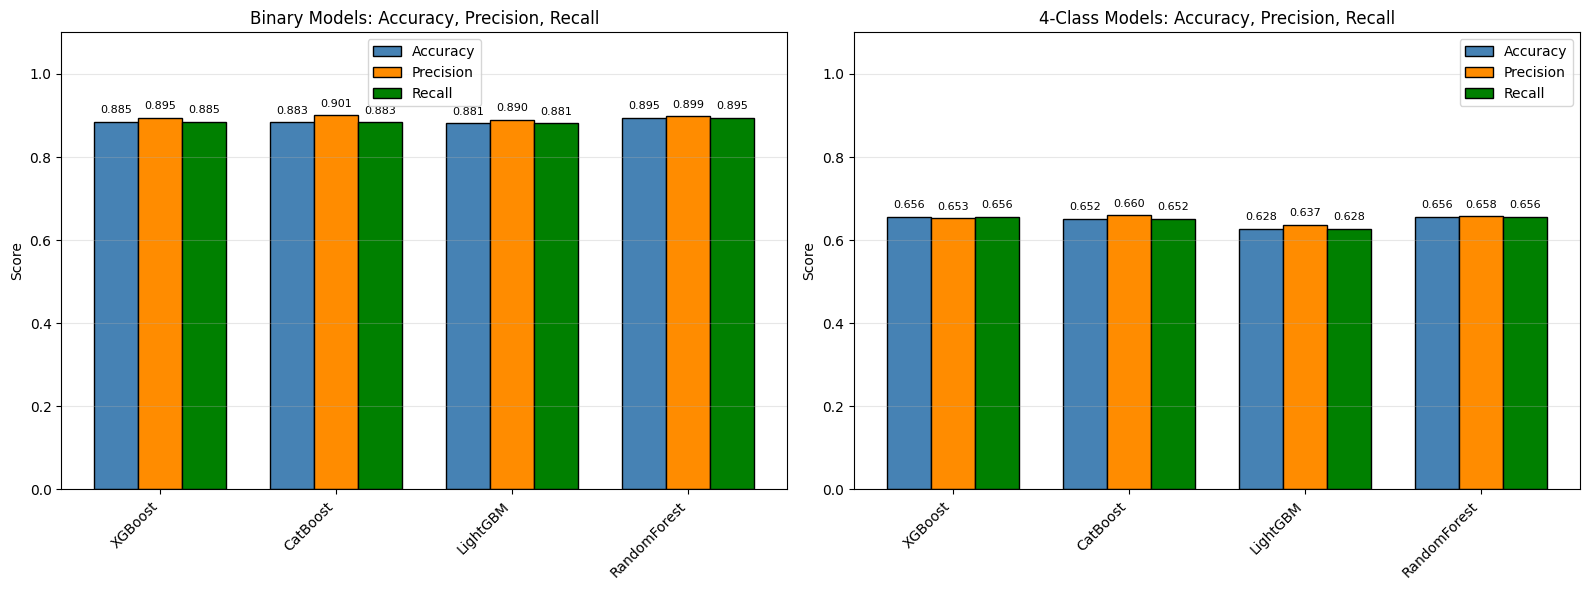

In [6]:
print("=" * 80)
print("VISUALIZATION: METRICS COMPARISON")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = list(results_binary.keys())
acc_binary = [results_binary[m]['accuracy'] for m in model_names]
prec_binary = [results_binary[m]['precision'] for m in model_names]
rec_binary = [results_binary[m]['recall'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

axes[0].bar(x - width, acc_binary, width, label='Accuracy', color='steelblue', edgecolor='black')
axes[0].bar(x, prec_binary, width, label='Precision', color='darkorange', edgecolor='black')
axes[0].bar(x + width, rec_binary, width, label='Recall', color='green', edgecolor='black')
axes[0].set_ylabel('Score')
axes[0].set_title('Binary Models: Accuracy, Precision, Recall')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].set_ylim([0, 1.1])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

for i, (acc, prec, rec) in enumerate(zip(acc_binary, prec_binary, rec_binary)):
    axes[0].text(i - width, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=8)
    axes[0].text(i, prec + 0.02, f'{prec:.3f}', ha='center', fontsize=8)
    axes[0].text(i + width, rec + 0.02, f'{rec:.3f}', ha='center', fontsize=8)

model_names_4 = list(results_4class.keys())
acc_4 = [results_4class[m]['accuracy'] for m in model_names_4]
prec_4 = [results_4class[m]['precision'] for m in model_names_4]
rec_4 = [results_4class[m]['recall'] for m in model_names_4]

x = np.arange(len(model_names_4))
axes[1].bar(x - width, acc_4, width, label='Accuracy', color='steelblue', edgecolor='black')
axes[1].bar(x, prec_4, width, label='Precision', color='darkorange', edgecolor='black')
axes[1].bar(x + width, rec_4, width, label='Recall', color='green', edgecolor='black')
axes[1].set_ylabel('Score')
axes[1].set_title('4-Class Models: Accuracy, Precision, Recall')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names_4, rotation=45, ha='right')
axes[1].set_ylim([0, 1.1])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

for i, (acc, prec, rec) in enumerate(zip(acc_4, prec_4, rec_4)):
    axes[1].text(i - width, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=8)
    axes[1].text(i, prec + 0.02, f'{prec:.3f}', ha='center', fontsize=8)
    axes[1].text(i + width, rec + 0.02, f'{rec:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/simple_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

VISUALIZATION: CONFUSION MATRICES


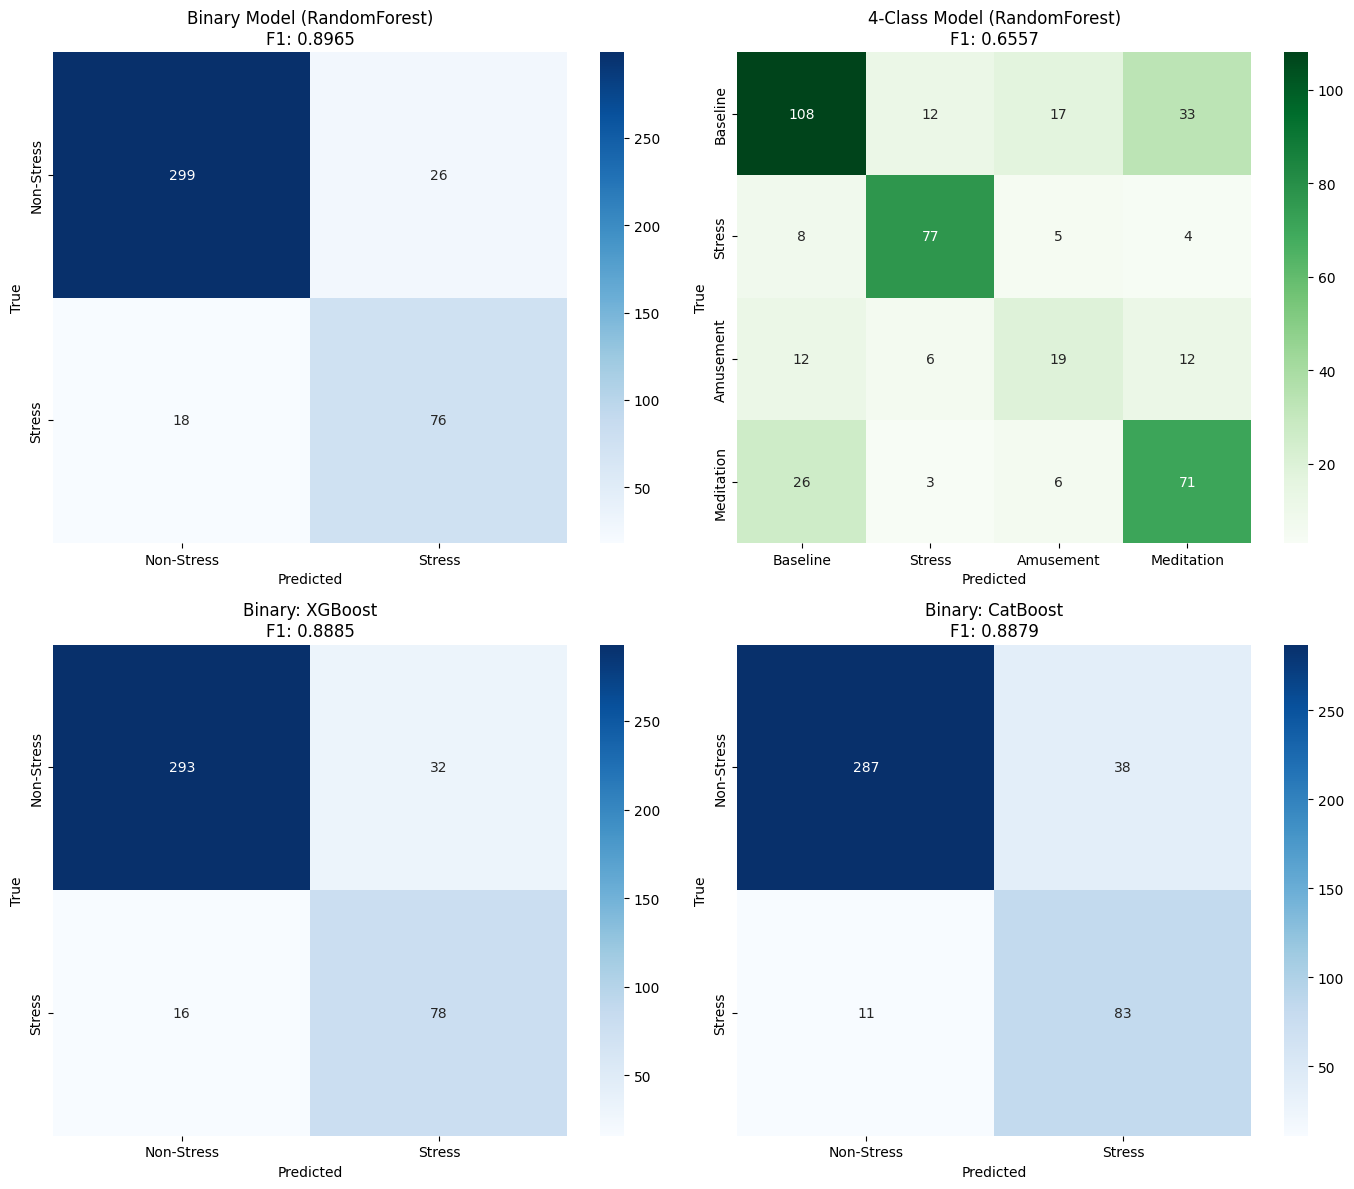

In [7]:
print("=" * 80)
print("VISUALIZATION: CONFUSION MATRICES")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

cm_binary_best = confusion_matrix(results_binary[best_binary_name]['y_test'], 
                                   results_binary[best_binary_name]['y_pred'])
sns.heatmap(cm_binary_best, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Non-Stress', 'Stress'],
            yticklabels=['Non-Stress', 'Stress'])
axes[0, 0].set_title(f'Binary Model ({best_binary_name})\nF1: {results_binary[best_binary_name]["f1_weighted"]:.4f}')
axes[0, 0].set_ylabel('True')
axes[0, 0].set_xlabel('Predicted')

cm_4class_best = confusion_matrix(results_4class[best_4class_name]['y_test'],
                                   results_4class[best_4class_name]['y_pred'])
sns.heatmap(cm_4class_best, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
            xticklabels=['Baseline', 'Stress', 'Amusement', 'Meditation'],
            yticklabels=['Baseline', 'Stress', 'Amusement', 'Meditation'])
axes[0, 1].set_title(f'4-Class Model ({best_4class_name})\nF1: {results_4class[best_4class_name]["f1_weighted"]:.4f}')
axes[0, 1].set_ylabel('True')
axes[0, 1].set_xlabel('Predicted')

for i, (name, res) in enumerate(list(results_binary.items())[:2]):
    if i >= 2:
        break
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, i],
                xticklabels=['Non-Stress', 'Stress'],
                yticklabels=['Non-Stress', 'Stress'])
    axes[1, i].set_title(f'Binary: {name}\nF1: {res["f1_weighted"]:.4f}')
    axes[1, i].set_ylabel('True')
    axes[1, i].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('outputs/simple_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

FEATURE IMPORTANCE


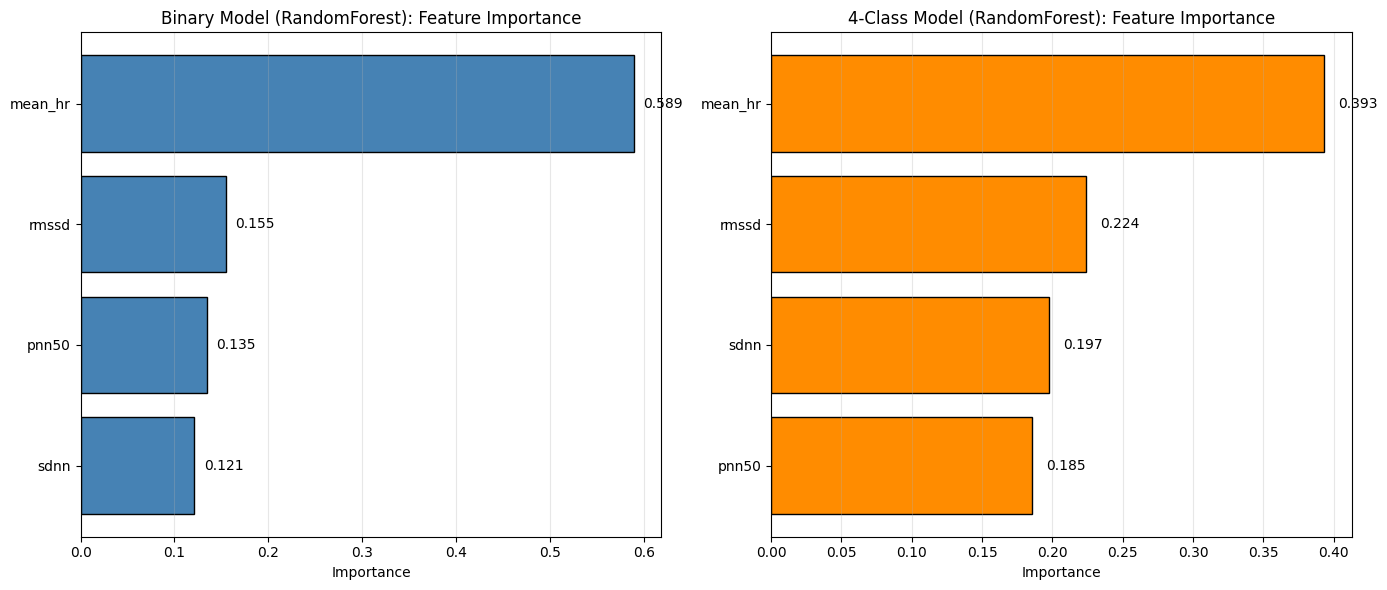


Feature Importance (Binary):
  1. mean_hr      0.5894
  2. rmssd        0.1550
  3. pnn50        0.1346
  4. sdnn         0.1211

Feature Importance (4-Class):
  1. mean_hr      0.3934
  2. rmssd        0.2239
  3. sdnn         0.1975
  4. pnn50        0.1852


In [8]:
print("=" * 80)
print("FEATURE IMPORTANCE")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

importances_binary = best_binary_model.feature_importances_
indices_binary = np.argsort(importances_binary)[::-1]

axes[0].barh(range(len(SIMPLE_FEATURE_NAMES)), importances_binary[indices_binary][::-1], 
             color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(SIMPLE_FEATURE_NAMES)))
axes[0].set_yticklabels([SIMPLE_FEATURE_NAMES[i] for i in indices_binary[::-1]])
axes[0].set_xlabel('Importance')
axes[0].set_title(f'Binary Model ({best_binary_name}): Feature Importance')
axes[0].grid(True, alpha=0.3, axis='x')

for i, (idx, imp) in enumerate(zip(indices_binary[::-1], importances_binary[indices_binary[::-1]])):
    axes[0].text(imp + 0.01, i, f'{imp:.3f}', va='center', fontsize=10)

importances_4class = best_4class_model.feature_importances_
indices_4class = np.argsort(importances_4class)[::-1]

axes[1].barh(range(len(SIMPLE_FEATURE_NAMES)), importances_4class[indices_4class][::-1],
             color='darkorange', edgecolor='black')
axes[1].set_yticks(range(len(SIMPLE_FEATURE_NAMES)))
axes[1].set_yticklabels([SIMPLE_FEATURE_NAMES[i] for i in indices_4class[::-1]])
axes[1].set_xlabel('Importance')
axes[1].set_title(f'4-Class Model ({best_4class_name}): Feature Importance')
axes[1].grid(True, alpha=0.3, axis='x')

for i, (idx, imp) in enumerate(zip(indices_4class[::-1], importances_4class[indices_4class[::-1]])):
    axes[1].text(imp + 0.01, i, f'{imp:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/simple_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Importance (Binary):")
for i, idx in enumerate(indices_binary):
    print(f"  {i+1}. {SIMPLE_FEATURE_NAMES[idx]:12s} {importances_binary[idx]:.4f}")

print("\nFeature Importance (4-Class):")
for i, idx in enumerate(indices_4class):
    print(f"  {i+1}. {SIMPLE_FEATURE_NAMES[idx]:12s} {importances_4class[idx]:.4f}")

In [9]:
print("=" * 80)
print("SAVING MODELS")
print("=" * 80)

Path('model').mkdir(exist_ok=True)

pickle.dump(best_binary_model, open('model/model_simple_binary.pkl', 'wb'))
print(f"Saved: model/model_simple_binary.pkl ({best_binary_name})")

pickle.dump(best_4class_model, open('model/model_simple_4class.pkl', 'wb'))
print(f"Saved: model/model_simple_4class.pkl ({best_4class_name})")

pickle.dump(scaler_simple, open('model/scaler_simple.pkl', 'wb'))
print("Saved: model/scaler_simple.pkl")

pickle.dump(SIMPLE_FEATURE_NAMES, open('model/feature_names_simple.pkl', 'wb'))
print("Saved: model/feature_names_simple.pkl")

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"\nBinary Model ({best_binary_name}):")
print(f"  F1-macro:    {results_binary[best_binary_name]['f1_macro']:.4f}")
print(f"  F1-weighted: {results_binary[best_binary_name]['f1_weighted']:.4f}")
print(f"  Accuracy:    {results_binary[best_binary_name]['accuracy']:.4f}")
print(f"  Precision:   {results_binary[best_binary_name]['precision']:.4f}")
print(f"  Recall:      {results_binary[best_binary_name]['recall']:.4f}")

print(f"\n4-Class Model ({best_4class_name}):")
print(f"  F1-macro:    {results_4class[best_4class_name]['f1_macro']:.4f}")
print(f"  F1-weighted: {results_4class[best_4class_name]['f1_weighted']:.4f}")
print(f"  Accuracy:    {results_4class[best_4class_name]['accuracy']:.4f}")
print(f"  Precision:   {results_4class[best_4class_name]['precision']:.4f}")
print(f"  Recall:      {results_4class[best_4class_name]['recall']:.4f}")

print("\nFiles saved:")
print("  - model/model_simple_binary.pkl")
print("  - model/model_simple_4class.pkl")
print("  - model/scaler_simple.pkl")
print("  - model/feature_names_simple.pkl")

SAVING MODELS
Saved: model/model_simple_binary.pkl (RandomForest)
Saved: model/model_simple_4class.pkl (RandomForest)
Saved: model/scaler_simple.pkl
Saved: model/feature_names_simple.pkl

SUMMARY

Binary Model (RandomForest):
  F1-macro:    0.8535
  F1-weighted: 0.8965
  Accuracy:    0.8950
  Precision:   0.8988
  Recall:      0.8950

4-Class Model (RandomForest):
  F1-macro:    0.6232
  F1-weighted: 0.6557
  Accuracy:    0.6563
  Precision:   0.6578
  Recall:      0.6563

Files saved:
  - model/model_simple_binary.pkl
  - model/model_simple_4class.pkl
  - model/scaler_simple.pkl
  - model/feature_names_simple.pkl
